# HEROS Phase 3 Refined — Q9: Land-Use Buffer Associations

**Research Question 9:** Look at the land-use buffer characteristics across sites and whether they are associated with PM2.5 and heat indicators.

**Date:** April 4, 2026  
**Dataset:** data/clean/data_HEROS_clean.parquet (48,123 rows × 46 cols)  
**Sites:** 12 open-space monitoring locations  
**Study Period:** July 19 – August 23, 2023  

---

## Executive Summary

This analysis examines how land-use patterns within 25m and 50m buffers around monitoring sites relate to air quality (PM2.5) and heat stress (WBGT) measurements. We investigate correlations, regression relationships, and site clustering patterns to understand environmental justice implications of urban form on public health outcomes.

## Dashboard & Layout Recommendations (for Design Team)

**Note**: AI-generated dashboard recommendations will be inserted here after consulting Claude API for optimal visualization layout and user experience design.

---

## 1. Setup and Data Loading

Import libraries, configure plotting, and load the HEROS dataset.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import statsmodels.api as sm
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100  # For inline display
plt.rcParams['savefig.dpi'] = 300  # For saved figures

# Create figures directory
fig_dir = Path('figures/phase3_refined')
fig_dir.mkdir(parents=True, exist_ok=True)

print("Libraries loaded and figure directory configured.")
print(f"Figure save directory: {fig_dir}")

Libraries loaded and figure directory configured.
Figure save directory: figures/phase3_refined


In [2]:
# Load HEROS dataset
data_path = Path('../../data/clean/data_HEROS_clean.parquet')
df = pd.read_parquet(data_path)

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Date range: {df.datetime.min()} to {df.datetime.max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Confirm key columns
pm25_col = 'pa_mean_pm2_5_atm_b_corr_2'
wbgt_col = 'kes_mean_wbgt_f'
site_col = 'site_id'

print(f"\nKey columns check:")
print(f"PM2.5 column '{pm25_col}': {pm25_col in df.columns}")
print(f"WBGT column '{wbgt_col}': {wbgt_col in df.columns}")
print(f"Site column '{site_col}': {site_col in df.columns}")

# Data completeness check
print(f"\nData completeness:")
print(f"PM2.5 non-null: {df[pm25_col].count():,} / {len(df):,} ({100*df[pm25_col].count()/len(df):.1f}%)")
print(f"WBGT non-null: {df[wbgt_col].count():,} / {len(df):,} ({100*df[wbgt_col].count()/len(df):.1f}%)")

# Sites
sites = df[site_col].unique()
print(f"\nSites: {len(sites)} unique")
for i, site in enumerate(sorted(sites), 1):
    n_obs = (df[site_col] == site).sum()
    print(f"  {i:2d}. {site:<20} | {n_obs:,} observations")

# Check for non-zero data in key columns
pm25_nonzero = (df[pm25_col] > 0).sum()
wbgt_range = df[wbgt_col].describe()

print(f"\nData validation:")
print(f"PM2.5 > 0 observations: {pm25_nonzero:,} ({100*pm25_nonzero/len(df):.1f}%)")
print(f"WBGT range: {wbgt_range['min']:.1f}°F to {wbgt_range['max']:.1f}°F (mean: {wbgt_range['mean']:.1f}°F)")

Dataset Overview:
Shape: (48123, 46)
Date range: 2023-07-19 16:40:00 to 2023-08-23 15:50:00
Memory usage: 20.1 MB

Key columns check:
PM2.5 column 'pa_mean_pm2_5_atm_b_corr_2': True
WBGT column 'kes_mean_wbgt_f': True
Site column 'site_id': True

Data completeness:
PM2.5 non-null: 47,009 / 48,123 (97.7%)
WBGT non-null: 46,404 / 48,123 (96.4%)

Sites: 12 unique
   1. berkley              | 2,445 observations
   2. castle               | 4,881 observations
   3. chin                 | 2,199 observations
   4. dewey                | 4,903 observations
   5. eliotnorton          | 3,888 observations
   6. greenway             | 4,893 observations
   7. lyndenboro           | 4,786 observations
   8. msh                  | 4,189 observations
   9. oxford               | 2,879 observations
  10. reggie               | 4,126 observations
  11. taitung              | 4,839 observations
  12. tufts                | 4,095 observations

Data validation:
PM2.5 > 0 observations: 47,009 (97.7%)
WBGT

## 2. Identify Land-Use Buffer Columns and Compute Site-Level Summaries

Identify all land-use buffer characteristics columns and aggregate data to site level.

In [3]:
# Identify land-use buffer columns
# Based on the dataset info, we know these exist:
landuse_keywords = ['Roads_Area_Percent', 'Greenspace_Area_Percent', 'Trees_Area_Percent', 
                   'Impervious_Area_Percent', 'Industrial_Area_Percent']

# Find all land-use columns (should have 25m and 50m variants)
landuse_cols = []
for col in df.columns:
    if any(keyword in col for keyword in landuse_keywords):
        landuse_cols.append(col)

landuse_cols.sort()
print(f"Identified {len(landuse_cols)} land-use buffer columns:")
for col in landuse_cols:
    dtype = df[col].dtype
    non_null = df[col].count()
    print(f"  {col:<35} | {dtype} | {non_null:,} non-null")

# Check for missing data in land-use columns
missing_landuse = df[landuse_cols].isnull().sum().sum()
print(f"\nTotal missing values in land-use columns: {missing_landuse}")

# Preview land-use data structure
print(f"\nLand-use data preview (first 5 rows):")
print(df[['site_id'] + landuse_cols].head())

# Check if land-use values are constant within sites (they should be)
landuse_variation = df.groupby('site_id')[landuse_cols].nunique().max()
print(f"\nLand-use variation within sites:")
print(f"Max unique values per site: {landuse_variation.max()}")
if landuse_variation.max() == 1:
    print("✓ Land-use values are constant within sites (as expected)")
else:
    print("⚠ Land-use values vary within some sites (unexpected)")

Identified 10 land-use buffer columns:
  Greenspace_Area_Percent_25m         | float64 | 48,123 non-null
  Greenspace_Area_Percent_50m         | float64 | 48,123 non-null
  Impervious_Area_Percent_25m         | float64 | 48,123 non-null
  Impervious_Area_Percent_50m         | float64 | 48,123 non-null
  Industrial_Area_Percent_25m         | float64 | 48,123 non-null
  Industrial_Area_Percent_50m         | float64 | 48,123 non-null
  Roads_Area_Percent_25m              | float64 | 48,123 non-null
  Roads_Area_Percent_50m              | float64 | 48,123 non-null
  Trees_Area_Percent_25m              | float64 | 48,123 non-null
  Trees_Area_Percent_50m              | float64 | 48,123 non-null

Total missing values in land-use columns: 0

Land-use data preview (first 5 rows):
   site_id  Greenspace_Area_Percent_25m  Greenspace_Area_Percent_50m  \
0  berkley                     0.259756                     0.168168   
1  berkley                     0.259756                     0.168168   
2

In [4]:
# Compute site-level summaries
print("Computing site-level summaries...")

# Aggregate environmental indicators (mean) and land-use characteristics (first value, since constant)
site_summary = df.groupby('site_id').agg({
    pm25_col: 'mean',
    wbgt_col: 'mean',
    **{col: 'first' for col in landuse_cols}  # Land-use is constant per site
}).round(3)

# Rename columns for clarity
site_summary = site_summary.rename(columns={
    pm25_col: 'Mean_PM25_ugm3',
    wbgt_col: 'Mean_WBGT_F'
})

print(f"\nSite-level summary DataFrame: {site_summary.shape}")
print(f"Sites: {len(site_summary)}")
print(f"Variables: {len(site_summary.columns)}")

# Display summary
print(f"\nSite-level Environmental Indicators:")
env_cols = ['Mean_PM25_ugm3', 'Mean_WBGT_F']
print(site_summary[env_cols].round(2).to_string())

print(f"\nSite-level Land-Use Characteristics (25m buffer):")
cols_25m = [col for col in landuse_cols if '25m' in col]
print(site_summary[cols_25m].round(1).to_string())

print(f"\nSite-level Land-Use Characteristics (50m buffer):")
cols_50m = [col for col in landuse_cols if '50m' in col]
print(site_summary[cols_50m].round(1).to_string())

# Quick statistics
print(f"\nEnvironmental indicators summary:")
for col in env_cols:
    mean_val = site_summary[col].mean()
    std_val = site_summary[col].std()
    min_val = site_summary[col].min()
    max_val = site_summary[col].max()
    print(f"  {col:<18} | Mean: {mean_val:.2f} | Std: {std_val:.2f} | Range: {min_val:.2f}-{max_val:.2f}")

print(f"\nLand-use variables summary (across all sites):")
for col in landuse_cols:
    mean_val = site_summary[col].mean()
    std_val = site_summary[col].std()
    min_val = site_summary[col].min()
    max_val = site_summary[col].max()
    print(f"  {col:<35} | Mean: {mean_val:.1f}% | Std: {std_val:.1f}% | Range: {min_val:.1f}%-{max_val:.1f}%")

Computing site-level summaries...

Site-level summary DataFrame: (12, 12)
Sites: 12
Variables: 12

Site-level Environmental Indicators:
             Mean_PM25_ugm3  Mean_WBGT_F
site_id                                 
berkley                9.53        66.10
castle                 8.18        66.76
chin                  10.49        66.01
dewey                  9.70        65.92
eliotnorton            9.29        65.48
greenway              10.72        65.73
lyndenboro            10.68        65.83
msh                    9.07        65.09
oxford                 7.92        65.60
reggie                 8.34        65.67
taitung                9.36        65.94
tufts                 10.04        66.21

Site-level Land-Use Characteristics (25m buffer):
             Greenspace_Area_Percent_25m  Impervious_Area_Percent_25m  Industrial_Area_Percent_25m  Roads_Area_Percent_25m  Trees_Area_Percent_25m
site_id                                                                                     

## 3. KPI Overview: Key Correlations Between Land-Use and Environmental Indicators

Compute correlations between land-use buffer variables and PM2.5/WBGT at the site level.

In [5]:
# Compute correlations between land-use variables and environmental indicators
results = []

env_indicators = ['Mean_PM25_ugm3', 'Mean_WBGT_F']
correlation_methods = ['pearson', 'spearman']

for env_var in env_indicators:
    for landuse_var in landuse_cols:
        for method in correlation_methods:
            # Compute correlation
            r, p_val = stats.pearsonr(site_summary[landuse_var], site_summary[env_var]) if method == 'pearson' else \
                      stats.spearmanr(site_summary[landuse_var], site_summary[env_var])
            
            # Significance flag
            sig_flag = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
            
            results.append({
                'Environmental_Indicator': env_var,
                'LandUse_Variable': landuse_var,
                'Method': method.title(),
                'Correlation_r': round(r, 3),
                'P_Value': round(p_val, 4),
                'Significance': sig_flag,
                'Abs_Correlation': abs(r)
            })

# Convert to DataFrame
corr_df = pd.DataFrame(results)

# Create KPI summary table focusing on Pearson correlations
kpi_pearson = corr_df[corr_df['Method'] == 'Pearson'].copy()

print("=== KPI OVERVIEW: TOP CORRELATIONS ===\n")

# Top 5 strongest associations for each environmental indicator
for env_var in env_indicators:
    subset = kpi_pearson[kpi_pearson['Environmental_Indicator'] == env_var].copy()
    top5 = subset.nlargest(5, 'Abs_Correlation')
    
    print(f"Top 5 correlations with {env_var}:")
    for _, row in top5.iterrows():
        landuse_short = row['LandUse_Variable'].replace('_Area_Percent', '').replace('_', ' ')
        print(f"  {landuse_short:<25} | r = {row['Correlation_r']:>6.3f} | p = {row['P_Value']:>6.4f} {row['Significance']}")
    print()

# Overall strongest correlations (absolute value)
print("Overall strongest correlations (|r| > 0.4):")
strong_corrs = kpi_pearson[kpi_pearson['Abs_Correlation'] > 0.4].sort_values('Abs_Correlation', ascending=False)
if len(strong_corrs) > 0:
    for _, row in strong_corrs.iterrows():
        landuse_short = row['LandUse_Variable'].replace('_Area_Percent', '').replace('_', ' ')
        env_short = row['Environmental_Indicator'].replace('Mean_', '').replace('_ugm3', '').replace('_F', '')
        print(f"  {landuse_short:<25} ↔ {env_short:<8} | r = {row['Correlation_r']:>6.3f} | p = {row['P_Value']:>6.4f} {row['Significance']}")
else:
    print("  No correlations with |r| > 0.4 found")

print(f"\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05")

# Save KPI summary
kpi_save_path = fig_dir / 'q9_kpi_correlation_summary.csv'
kpi_pearson.to_csv(kpi_save_path, index=False)
print(f"\nKPI correlation summary saved to: {kpi_save_path}")

=== KPI OVERVIEW: TOP CORRELATIONS ===

Top 5 correlations with Mean_PM25_ugm3:
  Roads 50m                 | r =  0.680 | p = 0.0150 *
  Roads 25m                 | r =  0.634 | p = 0.0269 *
  Greenspace 25m            | r =  0.569 | p = 0.0533 
  Greenspace 50m            | r =  0.512 | p = 0.0889 
  Industrial 25m            | r =  0.210 | p = 0.5122 

Top 5 correlations with Mean_WBGT_F:
  Impervious 25m            | r = -0.566 | p = 0.0548 
  Impervious 50m            | r = -0.520 | p = 0.0834 
  Trees 50m                 | r =  0.506 | p = 0.0930 
  Trees 25m                 | r =  0.490 | p = 0.1061 
  Roads 50m                 | r = -0.229 | p = 0.4747 

Overall strongest correlations (|r| > 0.4):
  Roads 50m                 ↔ PM25     | r =  0.680 | p = 0.0150 *
  Roads 25m                 ↔ PM25     | r =  0.634 | p = 0.0269 *
  Greenspace 25m            ↔ PM25     | r =  0.569 | p = 0.0533 
  Impervious 25m            ↔ WBGT     | r = -0.566 | p = 0.0548 
  Impervious 50m   

## 4. EDA: Scatter Plots of Land-Use Variables vs PM2.5 and WBGT by Site

Create detailed scatter plots for the most correlated land-use variables.

Top 3 land-use variables for PM2.5: ['Roads 50m', 'Roads 25m', 'Greenspace 25m']
Top 3 land-use variables for WBGT: ['Impervious 25m', 'Impervious 50m', 'Trees 50m']


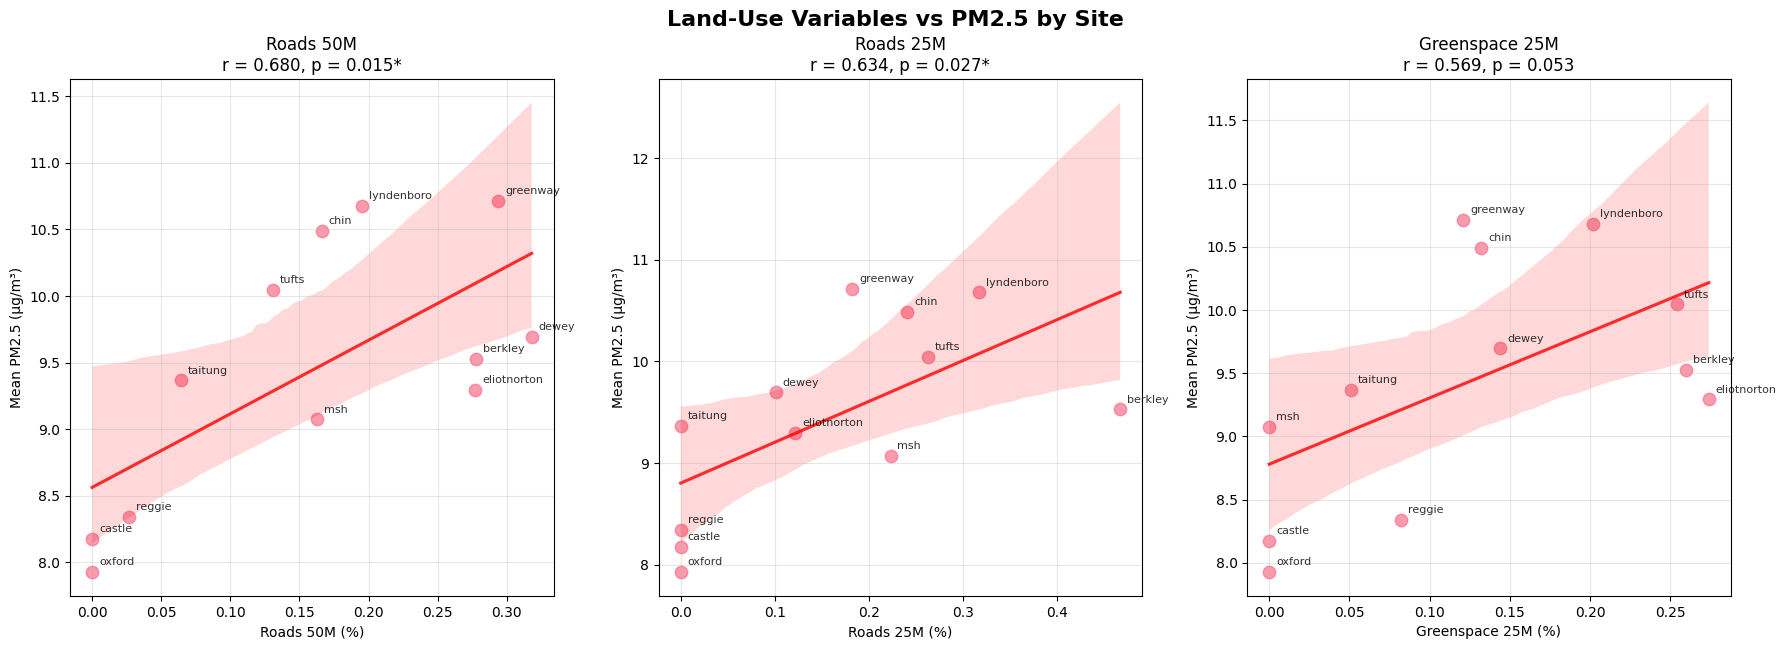

PM2.5 scatter plots saved to: figures/phase3_refined/q9_scatter_landuse_vs_pm25.png


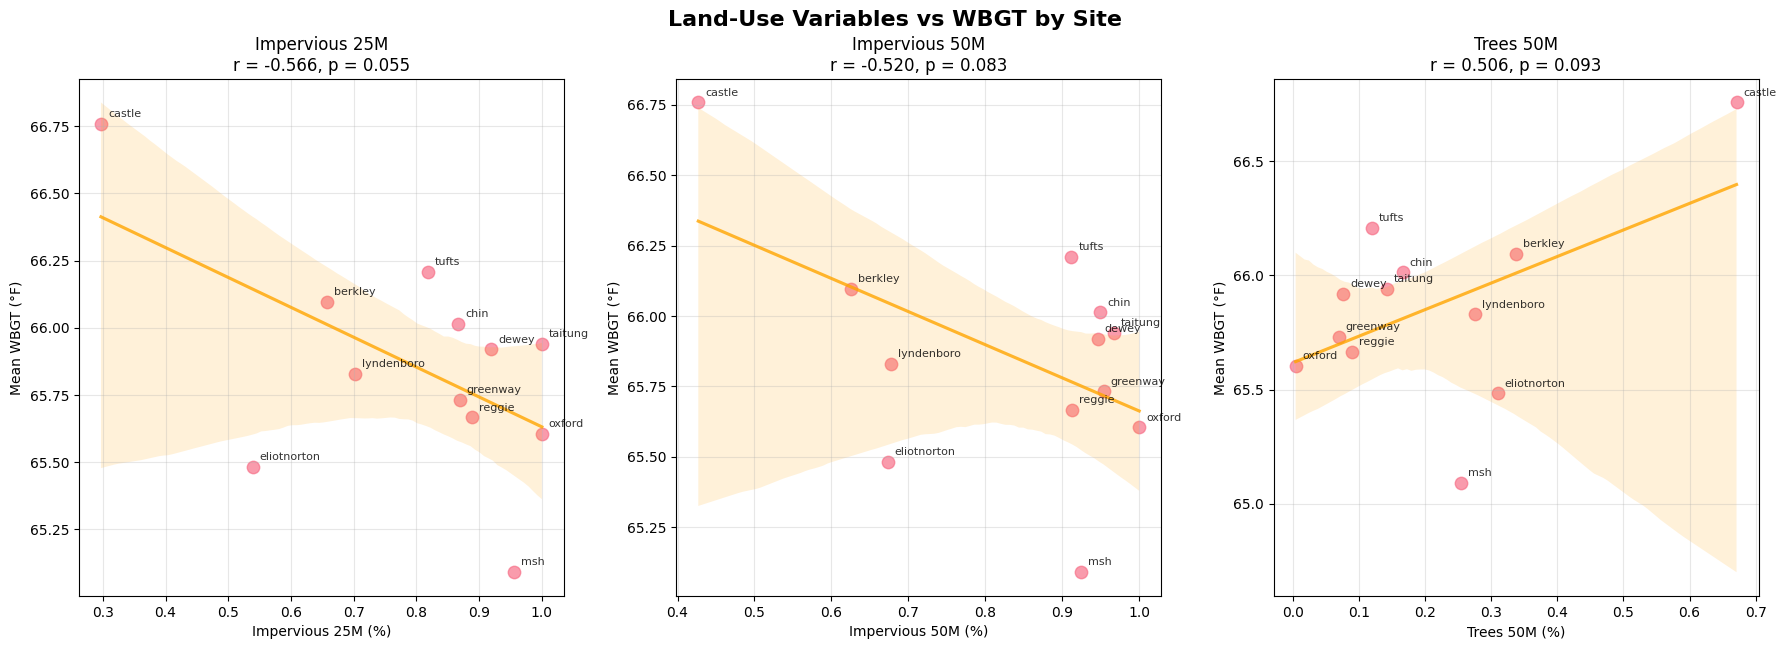

WBGT scatter plots saved to: figures/phase3_refined/q9_scatter_landuse_vs_wbgt.png


In [6]:
# Select top correlated variables for detailed visualization
top_vars_pm25 = kpi_pearson[kpi_pearson['Environmental_Indicator'] == 'Mean_PM25_ugm3'].nlargest(3, 'Abs_Correlation')['LandUse_Variable'].tolist()
top_vars_wbgt = kpi_pearson[kpi_pearson['Environmental_Indicator'] == 'Mean_WBGT_F'].nlargest(3, 'Abs_Correlation')['LandUse_Variable'].tolist()

print(f"Top 3 land-use variables for PM2.5: {[var.replace('_Area_Percent_', ' ').replace('_', ' ') for var in top_vars_pm25]}")
print(f"Top 3 land-use variables for WBGT: {[var.replace('_Area_Percent_', ' ').replace('_', ' ') for var in top_vars_wbgt]}")

# Create scatter plots for PM2.5
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Land-Use Variables vs PM2.5 by Site', fontsize=16, fontweight='bold')

for i, landuse_var in enumerate(top_vars_pm25):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # Scatter plot with regression line
    sns.regplot(data=site_summary, x=landuse_var, y='Mean_PM25_ugm3', ax=ax, 
                scatter_kws={'s': 80, 'alpha': 0.7}, line_kws={'color': 'red', 'alpha': 0.8})
    
    # Annotate points with site names
    for site_id in site_summary.index:
        ax.annotate(site_id, 
                   (site_summary.loc[site_id, landuse_var], site_summary.loc[site_id, 'Mean_PM25_ugm3']),
                   xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    
    # Get correlation info
    corr_info = kpi_pearson[(kpi_pearson['Environmental_Indicator'] == 'Mean_PM25_ugm3') & 
                          (kpi_pearson['LandUse_Variable'] == landuse_var)].iloc[0]
    
    # Format titles and labels
    title = landuse_var.replace('_Area_Percent_', ' ').replace('_', ' ').title()
    ax.set_title(f'{title}\nr = {corr_info["Correlation_r"]:.3f}, p = {corr_info["P_Value"]:.3f}{corr_info["Significance"]}')
    ax.set_xlabel(f'{title} (%)')
    ax.set_ylabel('Mean PM2.5 (µg/m³)')
    ax.grid(True, alpha=0.3)

# Remove empty subplots if any
for i in range(len(top_vars_pm25), 6):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()

# Save PM2.5 scatter plots
pm25_scatter_path = fig_dir / 'q9_scatter_landuse_vs_pm25.png'
plt.savefig(pm25_scatter_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"PM2.5 scatter plots saved to: {pm25_scatter_path}")

# Create scatter plots for WBGT
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Land-Use Variables vs WBGT by Site', fontsize=16, fontweight='bold')

for i, landuse_var in enumerate(top_vars_wbgt):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # Scatter plot with regression line
    sns.regplot(data=site_summary, x=landuse_var, y='Mean_WBGT_F', ax=ax, 
                scatter_kws={'s': 80, 'alpha': 0.7}, line_kws={'color': 'orange', 'alpha': 0.8})
    
    # Annotate points with site names
    for site_id in site_summary.index:
        ax.annotate(site_id, 
                   (site_summary.loc[site_id, landuse_var], site_summary.loc[site_id, 'Mean_WBGT_F']),
                   xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    
    # Get correlation info
    corr_info = kpi_pearson[(kpi_pearson['Environmental_Indicator'] == 'Mean_WBGT_F') & 
                          (kpi_pearson['LandUse_Variable'] == landuse_var)].iloc[0]
    
    # Format titles and labels
    title = landuse_var.replace('_Area_Percent_', ' ').replace('_', ' ').title()
    ax.set_title(f'{title}\nr = {corr_info["Correlation_r"]:.3f}, p = {corr_info["P_Value"]:.3f}{corr_info["Significance"]}')
    ax.set_xlabel(f'{title} (%)')
    ax.set_ylabel('Mean WBGT (°F)')
    ax.grid(True, alpha=0.3)

# Remove empty subplots if any
for i in range(len(top_vars_wbgt), 6):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()

# Save WBGT scatter plots
wbgt_scatter_path = fig_dir / 'q9_scatter_landuse_vs_wbgt.png'
plt.savefig(wbgt_scatter_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"WBGT scatter plots saved to: {wbgt_scatter_path}")

## 5. Correlation Heatmap of Land-Use Features vs Environmental Outcomes

Create comprehensive correlation heatmaps to visualize all relationships.

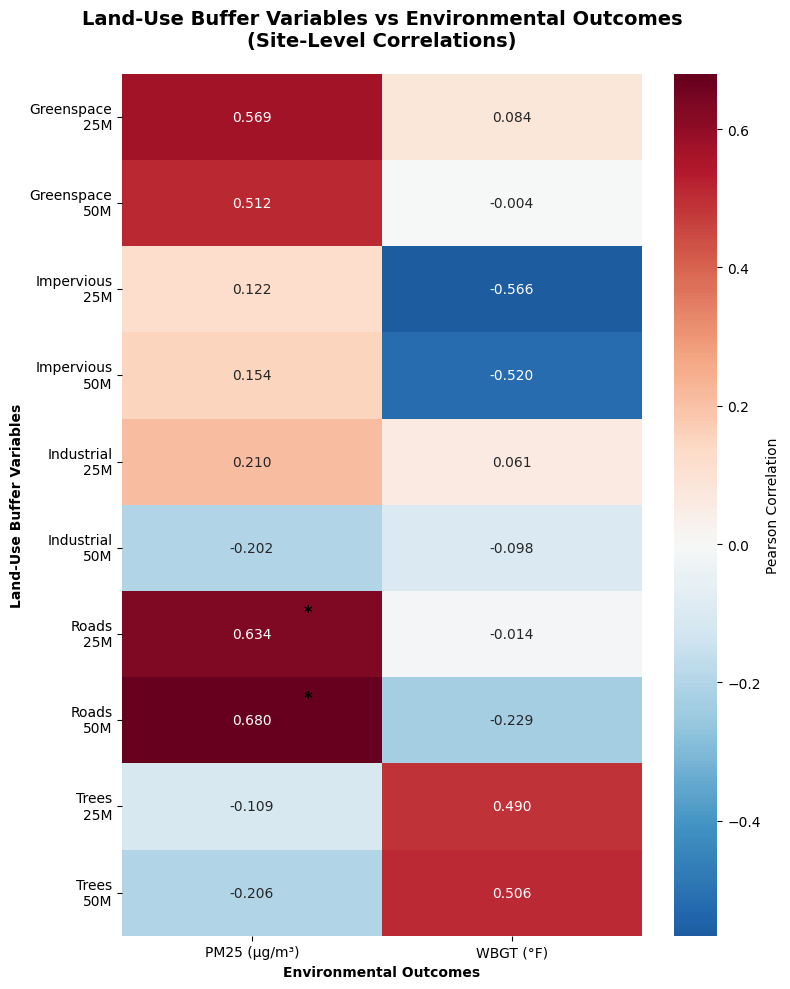

Land-use vs outcomes heatmap saved to: figures/phase3_refined/q9_heatmap_landuse_vs_outcomes.png
Significance codes: *** p<0.001, ** p<0.01, * p<0.05


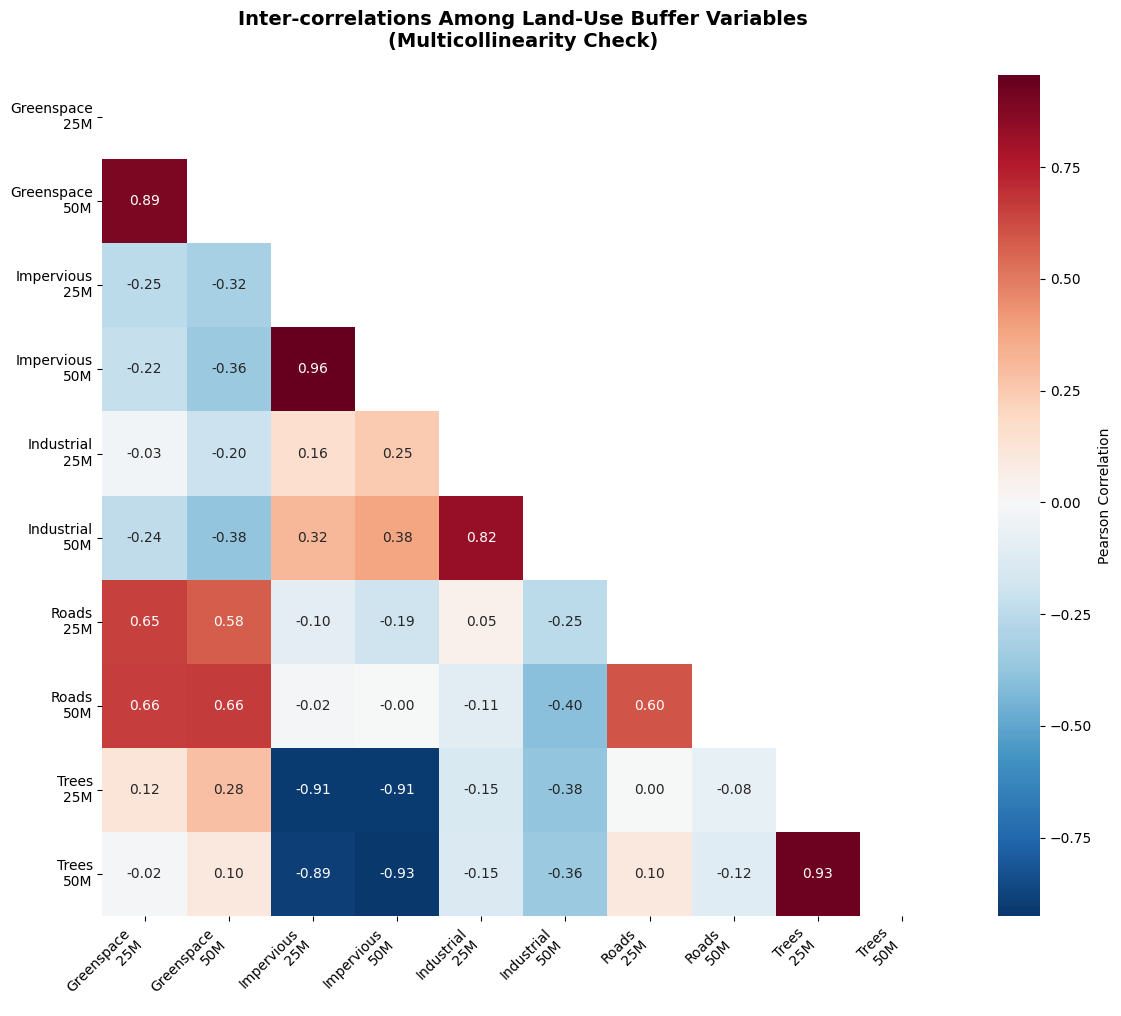

Land-use inter-correlation heatmap saved to: figures/phase3_refined/q9_heatmap_landuse_intercorrelation.png

=== MULTICOLLINEARITY CHECK ===
High correlations between land-use variables (|r| > 0.7):
  Greenspace 25m ↔ Greenspace 50m: r = 0.894
  Impervious 25m ↔ Impervious 50m: r = 0.956
  Impervious 25m ↔ Trees 25m: r = -0.912
  Impervious 25m ↔ Trees 50m: r = -0.895
  Impervious 50m ↔ Trees 25m: r = -0.908
  Impervious 50m ↔ Trees 50m: r = -0.926
  Industrial 25m ↔ Industrial 50m: r = 0.824
  Trees 25m ↔ Trees 50m: r = 0.929


In [7]:
# Correlation heatmap: Land-use vs Environmental outcomes
outcomes_cols = ['Mean_PM25_ugm3', 'Mean_WBGT_F']

# Compute correlation matrix
corr_matrix = site_summary[landuse_cols + outcomes_cols].corr()

# Extract just land-use vs outcomes
landuse_vs_outcomes = corr_matrix.loc[landuse_cols, outcomes_cols]

# Generate significance matrix for land-use vs outcomes
sig_matrix = np.zeros_like(landuse_vs_outcomes)
for i, landuse_var in enumerate(landuse_cols):
    for j, outcome_var in enumerate(outcomes_cols):
        _, p_val = stats.pearsonr(site_summary[landuse_var], site_summary[outcome_var])
        sig_matrix[i, j] = p_val

# Create significance annotations
sig_annotations = np.where(sig_matrix < 0.001, '***',
                  np.where(sig_matrix < 0.01, '**',
                  np.where(sig_matrix < 0.05, '*', '')))

# Plot land-use vs outcomes heatmap
fig, ax = plt.subplots(figsize=(8, 10))

# Create heatmap
sns.heatmap(landuse_vs_outcomes, annot=True, cmap='RdBu_r', center=0, 
           fmt='.3f', cbar_kws={'label': 'Pearson Correlation'},
           ax=ax, square=False)

# Add significance annotations
for i in range(len(landuse_cols)):
    for j in range(len(outcomes_cols)):
        if sig_annotations[i, j]:
            ax.text(j + 0.7, i + 0.3, sig_annotations[i, j], 
                   fontsize=12, fontweight='bold', color='black')

ax.set_title('Land-Use Buffer Variables vs Environmental Outcomes\n(Site-Level Correlations)', 
            fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Environmental Outcomes', fontweight='bold')
ax.set_ylabel('Land-Use Buffer Variables', fontweight='bold')

# Clean up y-axis labels
yticklabels = [label.get_text().replace('_Area_Percent_', '\n').replace('_', ' ').title() 
              for label in ax.get_yticklabels()]
ax.set_yticklabels(yticklabels, rotation=0)

# Clean up x-axis labels
xticklabels = [label.get_text().replace('Mean_', '').replace('_ugm3', ' (µg/m³)').replace('_F', ' (°F)') 
              for label in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels, rotation=0)

plt.tight_layout()

# Save heatmap
heatmap_outcomes_path = fig_dir / 'q9_heatmap_landuse_vs_outcomes.png'
plt.savefig(heatmap_outcomes_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Land-use vs outcomes heatmap saved to: {heatmap_outcomes_path}")
print(f"Significance codes: *** p<0.001, ** p<0.01, * p<0.05")

# Inter-correlation heatmap among land-use variables
landuse_corr = corr_matrix.loc[landuse_cols, landuse_cols]

fig, ax = plt.subplots(figsize=(12, 10))

# Mask upper triangle to show only lower half
mask = np.triu(np.ones_like(landuse_corr, dtype=bool))

sns.heatmap(landuse_corr, mask=mask, annot=True, cmap='RdBu_r', center=0, 
           fmt='.2f', cbar_kws={'label': 'Pearson Correlation'},
           ax=ax, square=True)

ax.set_title('Inter-correlations Among Land-Use Buffer Variables\n(Multicollinearity Check)', 
            fontsize=14, fontweight='bold', pad=20)

# Clean up labels
labels = [label.get_text().replace('_Area_Percent_', '\n').replace('_', ' ').title() 
         for label in ax.get_yticklabels()]
ax.set_yticklabels(labels, rotation=0)
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()

# Save inter-correlation heatmap
intercorr_path = fig_dir / 'q9_heatmap_landuse_intercorrelation.png'
plt.savefig(intercorr_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Land-use inter-correlation heatmap saved to: {intercorr_path}")

# Summary of strong correlations
print("\n=== MULTICOLLINEARITY CHECK ===")
high_corr_pairs = []
for i in range(len(landuse_cols)):
    for j in range(i+1, len(landuse_cols)):
        corr_val = landuse_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((landuse_cols[i], landuse_cols[j], corr_val))

if high_corr_pairs:
    print("High correlations between land-use variables (|r| > 0.7):")
    for var1, var2, corr in high_corr_pairs:
        print(f"  {var1.replace('_Area_Percent_', ' ').replace('_', ' ')} ↔ {var2.replace('_Area_Percent_', ' ').replace('_', ' ')}: r = {corr:.3f}")
else:
    print("✓ No extremely high correlations (|r| > 0.7) between land-use variables")

## 6. Regression Analysis: Predicting PM2.5 and WBGT from Land-Use Features

Fit regression models to quantify land-use effects on environmental outcomes.

In [8]:
# Regression Analysis
regression_results = []

print("=== UNIVARIATE REGRESSION ANALYSIS ===\n")

# Univariate regressions for each environmental indicator
for outcome in outcomes_cols:
    print(f"Predicting {outcome}:")
    print("-" * 50)
    
    for predictor in landuse_cols:
        # Prepare data
        y = site_summary[outcome]
        x = site_summary[predictor]
        X = sm.add_constant(x)  # Add intercept
        
        # Fit model
        model = sm.OLS(y, X).fit()
        
        # Extract results
        coef = model.params.iloc[1]  # Slope coefficient
        coef_pval = model.pvalues.iloc[1]
        r_squared = model.rsquared
        adj_r_squared = model.rsquared_adj
        
        # Store results
        regression_results.append({
            'Outcome': outcome,
            'Predictor': predictor,
            'Coefficient': coef,
            'Coefficient_PValue': coef_pval,
            'R_Squared': r_squared,
            'Adj_R_Squared': adj_r_squared,
            'Model_Type': 'Univariate'
        })
        
        # Display summary
        predictor_short = predictor.replace('_Area_Percent_', ' ').replace('_', ' ')
        sig_flag = '***' if coef_pval < 0.001 else '**' if coef_pval < 0.01 else '*' if coef_pval < 0.05 else ''
        print(f"  {predictor_short:<30} | β = {coef:>7.4f} | R² = {r_squared:>5.3f} | p = {coef_pval:>6.4f} {sig_flag}")
    
    print()

# Convert to DataFrame for easier analysis
regression_df = pd.DataFrame(regression_results)

print("\n=== BEST UNIVARIATE PREDICTORS ===")

# Best predictors for each outcome
for outcome in outcomes_cols:
    subset = regression_df[regression_df['Outcome'] == outcome]
    best = subset.loc[subset['R_Squared'].idxmax()]
    
    outcome_short = outcome.replace('Mean_', '').replace('_ugm3', '').replace('_F', '')
    predictor_short = best['Predictor'].replace('_Area_Percent_', ' ').replace('_', ' ')
    
    print(f"{outcome_short}: {predictor_short} (R² = {best['R_Squared']:.3f}, p = {best['Coefficient_PValue']:.4f})")

print("\n=== MULTIVARIATE MODELS (TOP 2 UNCORRELATED PREDICTORS) ===\n")

# For multivariate analysis, select top 2 uncorrelated predictors for each outcome
multivar_results = []

for outcome in outcomes_cols:
    print(f"Multivariate model for {outcome}:")
    
    # Get top predictors by R-squared
    subset = regression_df[regression_df['Outcome'] == outcome].sort_values('R_Squared', ascending=False)
    
    # Select top 2 that are not highly correlated with each other
    selected_predictors = []
    for _, row in subset.iterrows():
        predictor = row['Predictor']
        
        # Check correlation with already selected predictors
        if len(selected_predictors) == 0:
            selected_predictors.append(predictor)
        else:
            # Check correlation with existing predictors
            max_corr = max([abs(corr_matrix.loc[predictor, existing]) for existing in selected_predictors])
            if max_corr < 0.7 and len(selected_predictors) < 2:  # Keep uncorrelated predictors
                selected_predictors.append(predictor)
        
        if len(selected_predictors) >= 2:
            break
    
    # Fit multivariate model
    if len(selected_predictors) >= 2:
        y = site_summary[outcome]
        X = site_summary[selected_predictors]
        X = sm.add_constant(X)
        
        multivar_model = sm.OLS(y, X).fit()
        
        print(f"  Predictors: {[p.replace('_Area_Percent_', ' ').replace('_', ' ') for p in selected_predictors]}")
        print(f"  R² = {multivar_model.rsquared:.3f}")
        print(f"  Adj R² = {multivar_model.rsquared_adj:.3f}")
        print(f"  F-statistic p-value: {multivar_model.f_pvalue:.4f}")
        
        # Store multivariate results
        for i, predictor in enumerate(selected_predictors):
            coef = multivar_model.params.iloc[i+1]  # Skip intercept
            pval = multivar_model.pvalues.iloc[i+1]
            
            multivar_results.append({
                'Outcome': outcome,
                'Predictor': predictor,
                'Coefficient': coef,
                'Coefficient_PValue': pval,
                'R_Squared': multivar_model.rsquared,
                'Adj_R_Squared': multivar_model.rsquared_adj,
                'Model_Type': 'Multivariate'
            })
        
        print(f"  Model summary:")
        for i, predictor in enumerate(selected_predictors):
            coef = multivar_model.params.iloc[i+1]
            pval = multivar_model.pvalues.iloc[i+1]
            sig_flag = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            predictor_short = predictor.replace('_Area_Percent_', ' ').replace('_', ' ')
            print(f"    {predictor_short:<25} | β = {coef:>7.4f} | p = {pval:>6.4f} {sig_flag}")
    else:
        print(f"  Only {len(selected_predictors)} uncorrelated predictor(s) found")
    
    print()

# Combine results
all_regression_results = regression_results + multivar_results
regression_summary_df = pd.DataFrame(all_regression_results)

# Save regression summary
regression_summary_path = fig_dir / 'q9_regression_summary.csv'
regression_summary_df.to_csv(regression_summary_path, index=False)
print(f"Regression summary saved to: {regression_summary_path}")

=== UNIVARIATE REGRESSION ANALYSIS ===

Predicting Mean_PM25_ugm3:
--------------------------------------------------
  Greenspace 25m                 | β =  5.2399 | R² = 0.324 | p = 0.0533 
  Greenspace 50m                 | β =  5.9760 | R² = 0.262 | p = 0.0889 
  Impervious 25m                 | β =  0.5544 | R² = 0.015 | p = 0.7047 
  Impervious 50m                 | β =  0.8047 | R² = 0.024 | p = 0.6325 
  Industrial 25m                 | β =  8.8449 | R² = 0.044 | p = 0.5122 
  Industrial 50m                 | β = -3.9832 | R² = 0.041 | p = 0.5288 
  Roads 25m                      | β =  4.0189 | R² = 0.402 | p = 0.0269 *
  Roads 50m                      | β =  5.5278 | R² = 0.462 | p = 0.0150 *
  Trees 25m                      | β = -0.5194 | R² = 0.012 | p = 0.7351 
  Trees 50m                      | β = -1.0918 | R² = 0.042 | p = 0.5206 

Predicting Mean_WBGT_F:
--------------------------------------------------
  Greenspace 25m                 | β =  0.3334 | R² = 0.007 | p 

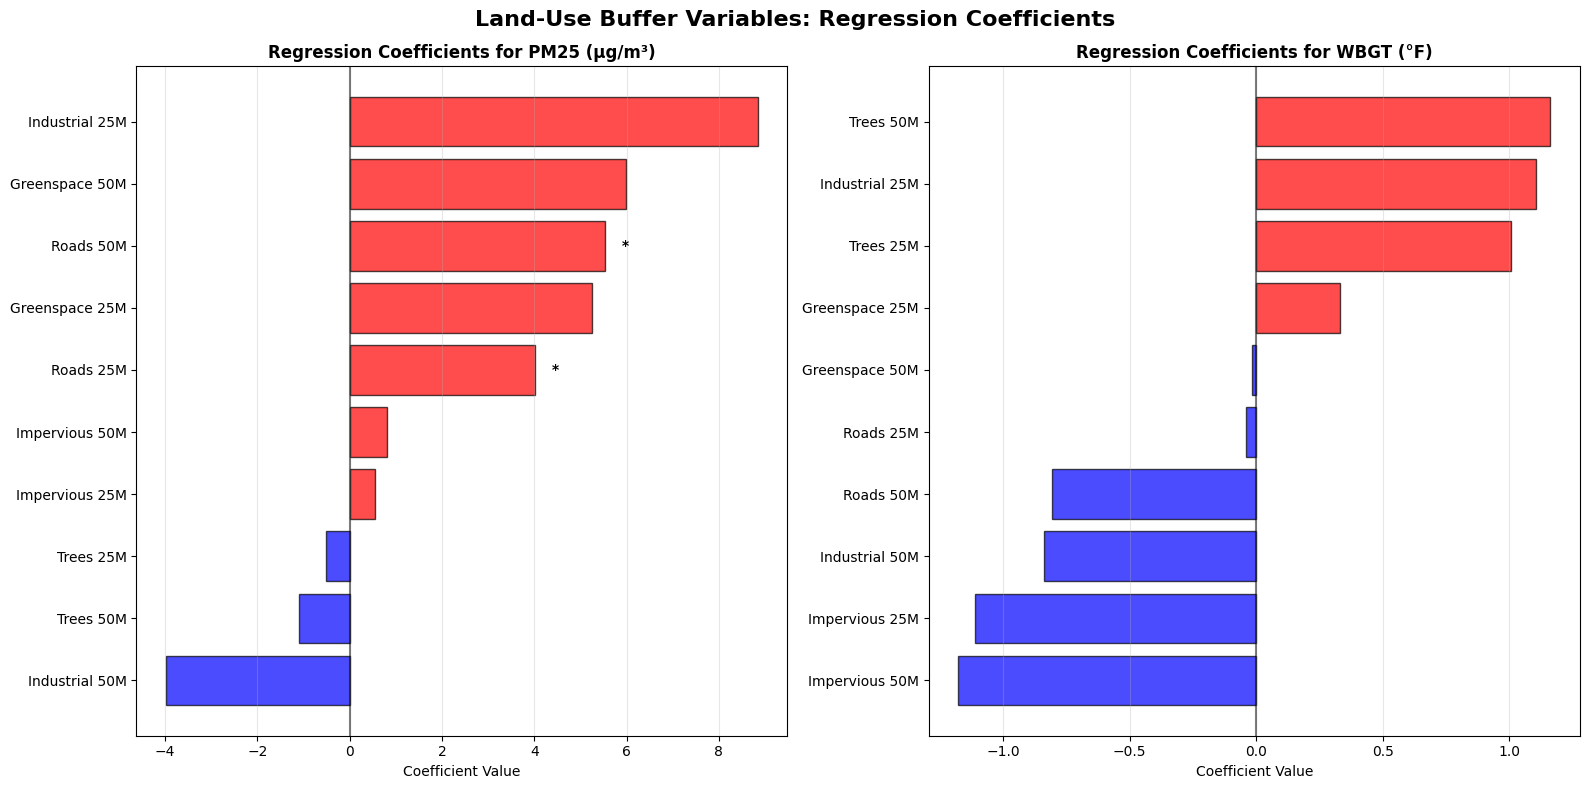

Regression coefficients plot saved to: figures/phase3_refined/q9_regression_coefficients.png


In [9]:
# Create coefficient plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot coefficients for each outcome
for i, outcome in enumerate(outcomes_cols):
    ax = axes[i]
    
    # Get univariate results for this outcome
    subset = regression_df[regression_df['Outcome'] == outcome].copy()
    subset = subset.sort_values('Coefficient', ascending=True)
    
    # Create coefficient plot with error bars
    colors = ['red' if coef > 0 else 'blue' for coef in subset['Coefficient']]
    
    # Bar plot
    bars = ax.barh(range(len(subset)), subset['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
    
    # Add significance markers
    for j, (_, row) in enumerate(subset.iterrows()):
        if row['Coefficient_PValue'] < 0.05:
            marker = '***' if row['Coefficient_PValue'] < 0.001 else '**' if row['Coefficient_PValue'] < 0.01 else '*'
            # Position marker at end of bar
            x_pos = row['Coefficient'] + (0.05 * max(abs(subset['Coefficient'])) * (1 if row['Coefficient'] > 0 else -1))
            ax.text(x_pos, j, marker, va='center', ha='center' if row['Coefficient'] > 0 else 'center', 
                   fontweight='bold', fontsize=10)
    
    # Formatting
    outcome_short = outcome.replace('Mean_', '').replace('_ugm3', ' (µg/m³)').replace('_F', ' (°F)')
    ax.set_title(f'Regression Coefficients for {outcome_short}', fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    
    # Y-axis labels
    predictor_labels = [p.replace('_Area_Percent_', ' ').replace('_', ' ').title() for p in subset['Predictor']]
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(predictor_labels)
    
    # Add vertical line at zero
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Land-Use Buffer Variables: Regression Coefficients', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save coefficient plot
coef_plot_path = fig_dir / 'q9_regression_coefficients.png'
plt.savefig(coef_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Regression coefficients plot saved to: {coef_plot_path}")

## 7. Site Clustering by Land-Use Characteristics

Cluster sites based on land-use patterns and examine environmental outcomes.

=== DIMENSIONALITY REDUCTION: PCA ===
Explained variance ratio:
  PC1: 0.441 (44.1%)
  PC2: 0.286 (28.6%)
  PC3: 0.153 (15.3%)
  PC4: 0.055 (5.5%)
Cumulative variance explained by first 2 PCs: 0.727 (72.7%)


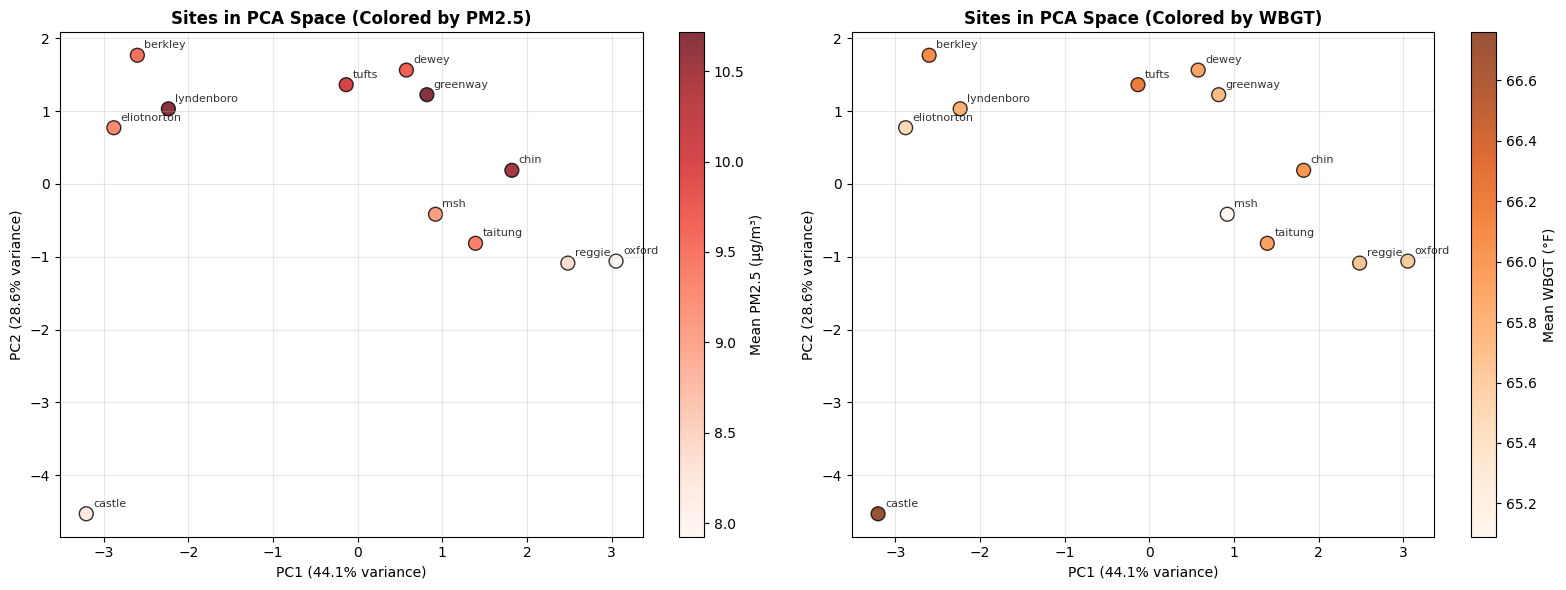

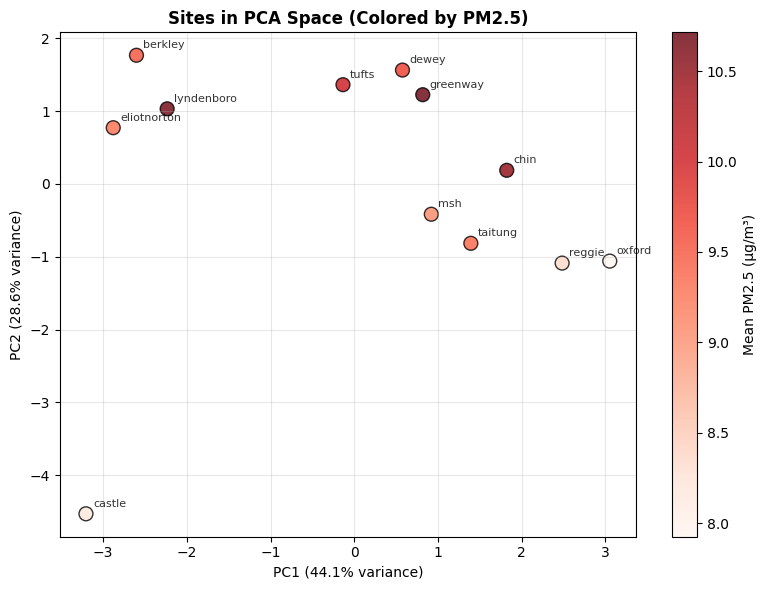

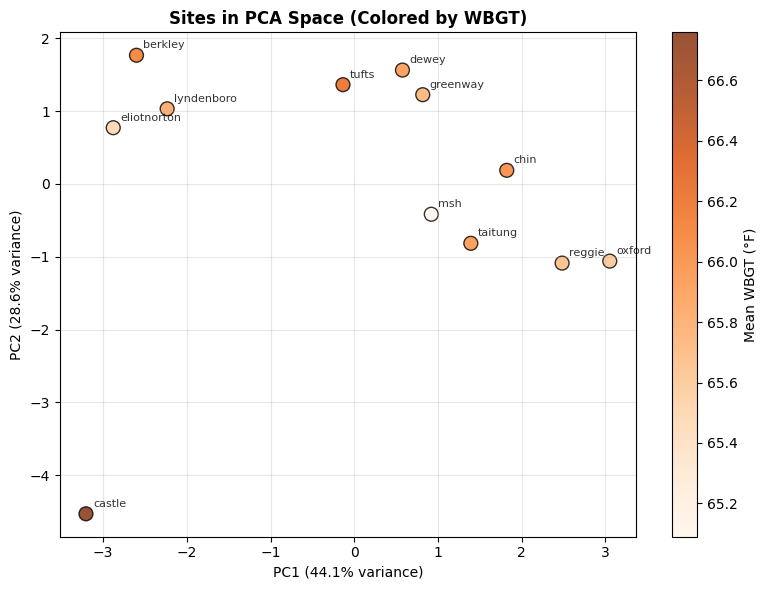

PCA plots saved to: figures/phase3_refined/q9_pca_sites_pm25.png and figures/phase3_refined/q9_pca_sites_wbgt.png

=== HIERARCHICAL CLUSTERING ===


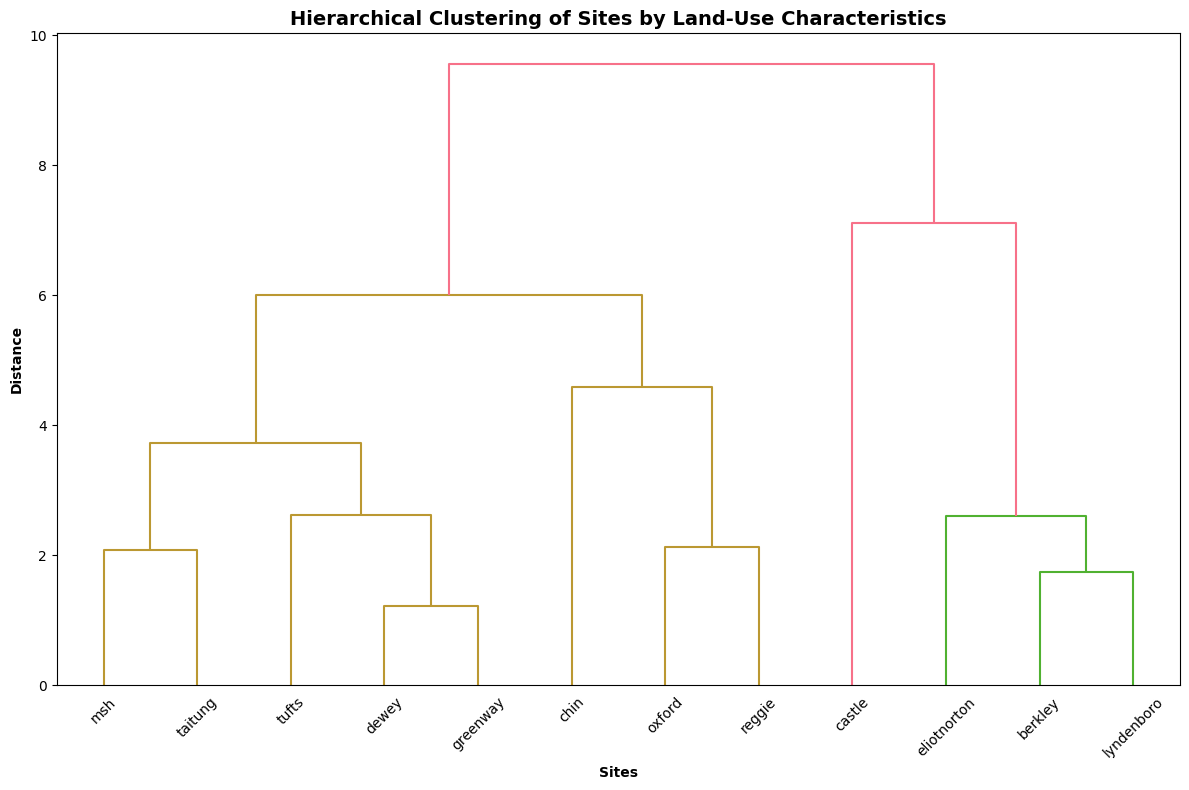

Dendrogram saved to: figures/phase3_refined/q9_dendrogram_landuse.png


In [10]:
# Standardize land-use features for clustering
scaler = StandardScaler()
landuse_data = site_summary[landuse_cols]
landuse_scaled = scaler.fit_transform(landuse_data)

print("=== DIMENSIONALITY REDUCTION: PCA ===")

# Apply PCA
pca = PCA()
pca_features = pca.fit_transform(landuse_scaled)

# PCA results
print(f"Explained variance ratio:")
for i, var_ratio in enumerate(pca.explained_variance_ratio_[:4], 1):
    print(f"  PC{i}: {var_ratio:.3f} ({var_ratio*100:.1f}%)")

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"Cumulative variance explained by first 2 PCs: {cumulative_variance[1]:.3f} ({cumulative_variance[1]*100:.1f}%)")

# Create PCA plots colored by environmental outcomes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA colored by PM2.5
ax = axes[0]
scatter = ax.scatter(pca_features[:, 0], pca_features[:, 1], 
                    c=site_summary['Mean_PM25_ugm3'], s=100, alpha=0.8, 
                    cmap='Reds', edgecolors='black', linewidth=1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Sites in PCA Space (Colored by PM2.5)', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mean PM2.5 (µg/m³)')

# Add site labels
for i, site_id in enumerate(site_summary.index):
    ax.annotate(site_id, (pca_features[i, 0], pca_features[i, 1]), 
               xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

ax.grid(True, alpha=0.3)

# PCA colored by WBGT
ax = axes[1]
scatter = ax.scatter(pca_features[:, 0], pca_features[:, 1], 
                    c=site_summary['Mean_WBGT_F'], s=100, alpha=0.8, 
                    cmap='Oranges', edgecolors='black', linewidth=1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Sites in PCA Space (Colored by WBGT)', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mean WBGT (°F)')

# Add site labels
for i, site_id in enumerate(site_summary.index):
    ax.annotate(site_id, (pca_features[i, 0], pca_features[i, 1]), 
               xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save PCA plots
pca_pm25_path = fig_dir / 'q9_pca_sites_pm25.png'
pca_wbgt_path = fig_dir / 'q9_pca_sites_wbgt.png'

# Save individual PCA plots
fig1, ax1 = plt.subplots(figsize=(8, 6))
scatter1 = ax1.scatter(pca_features[:, 0], pca_features[:, 1], 
                      c=site_summary['Mean_PM25_ugm3'], s=100, alpha=0.8, 
                      cmap='Reds', edgecolors='black', linewidth=1)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('Sites in PCA Space (Colored by PM2.5)', fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Mean PM2.5 (µg/m³)')
for i, site_id in enumerate(site_summary.index):
    ax1.annotate(site_id, (pca_features[i, 0], pca_features[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(pca_pm25_path, dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
scatter2 = ax2.scatter(pca_features[:, 0], pca_features[:, 1], 
                      c=site_summary['Mean_WBGT_F'], s=100, alpha=0.8, 
                      cmap='Oranges', edgecolors='black', linewidth=1)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax2.set_title('Sites in PCA Space (Colored by WBGT)', fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Mean WBGT (°F)')
for i, site_id in enumerate(site_summary.index):
    ax2.annotate(site_id, (pca_features[i, 0], pca_features[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(pca_wbgt_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"PCA plots saved to: {pca_pm25_path} and {pca_wbgt_path}")

print("\n=== HIERARCHICAL CLUSTERING ===")

# Hierarchical clustering
linkage_matrix = linkage(landuse_scaled, method='ward')

# Create dendrogram
fig, ax = plt.subplots(figsize=(12, 8))
dendro = dendrogram(linkage_matrix, labels=site_summary.index.tolist(), 
                   ax=ax, leaf_rotation=45, leaf_font_size=10)
ax.set_title('Hierarchical Clustering of Sites by Land-Use Characteristics', fontweight='bold', fontsize=14)
ax.set_xlabel('Sites', fontweight='bold')
ax.set_ylabel('Distance', fontweight='bold')

plt.tight_layout()

# Save dendrogram
dendro_path = fig_dir / 'q9_dendrogram_landuse.png'
plt.savefig(dendro_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Dendrogram saved to: {dendro_path}")


=== K-MEANS CLUSTERING ===
k=2: Silhouette Score = 0.317
k=3: Silhouette Score = 0.312
k=4: Silhouette Score = 0.278
k=5: Silhouette Score = 0.233

Optimal k = 2 (highest silhouette score: 0.317)

Cluster assignments:
  Cluster 0: ['berkley', 'castle', 'eliotnorton', 'lyndenboro']
  Cluster 1: ['chin', 'dewey', 'greenway', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']


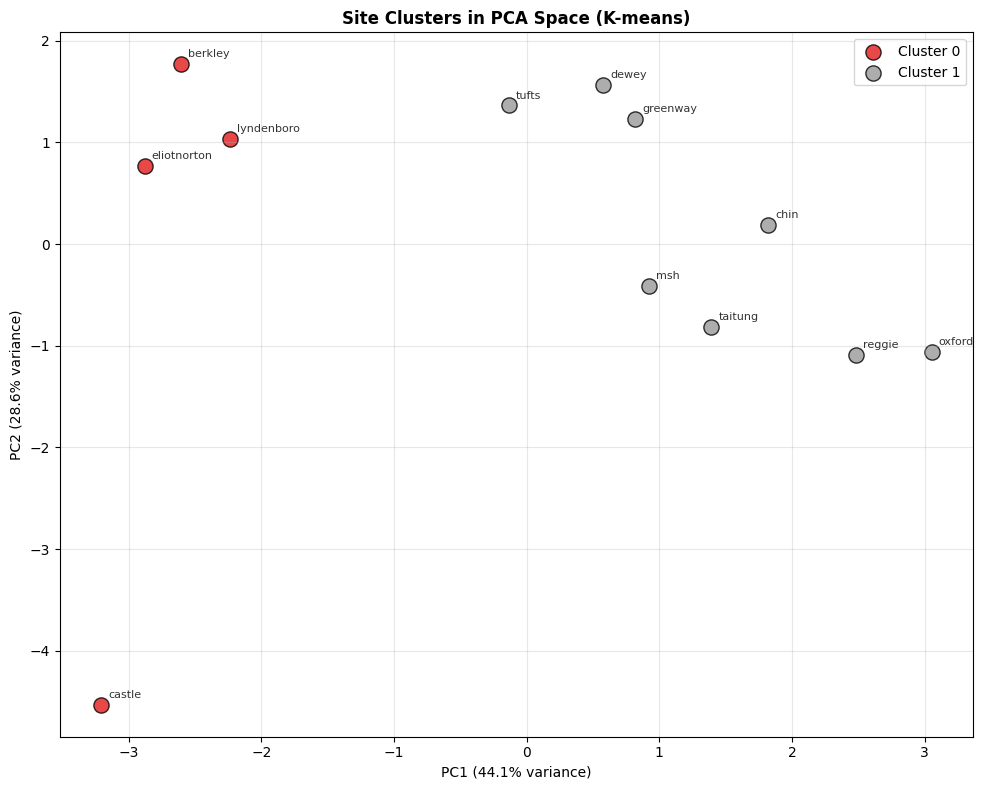


=== CLUSTER COMPARISON: ENVIRONMENTAL OUTCOMES ===
        Mean_PM25_ugm3        Mean_WBGT_F       
                  mean    std        mean    std
Cluster                                         
0                9.418  1.026      66.041  0.540
1                9.456  0.985      65.772  0.339
PM25 between clusters (t-test): p = 0.9518 
WBGT between clusters (t-test): p = 0.3080 


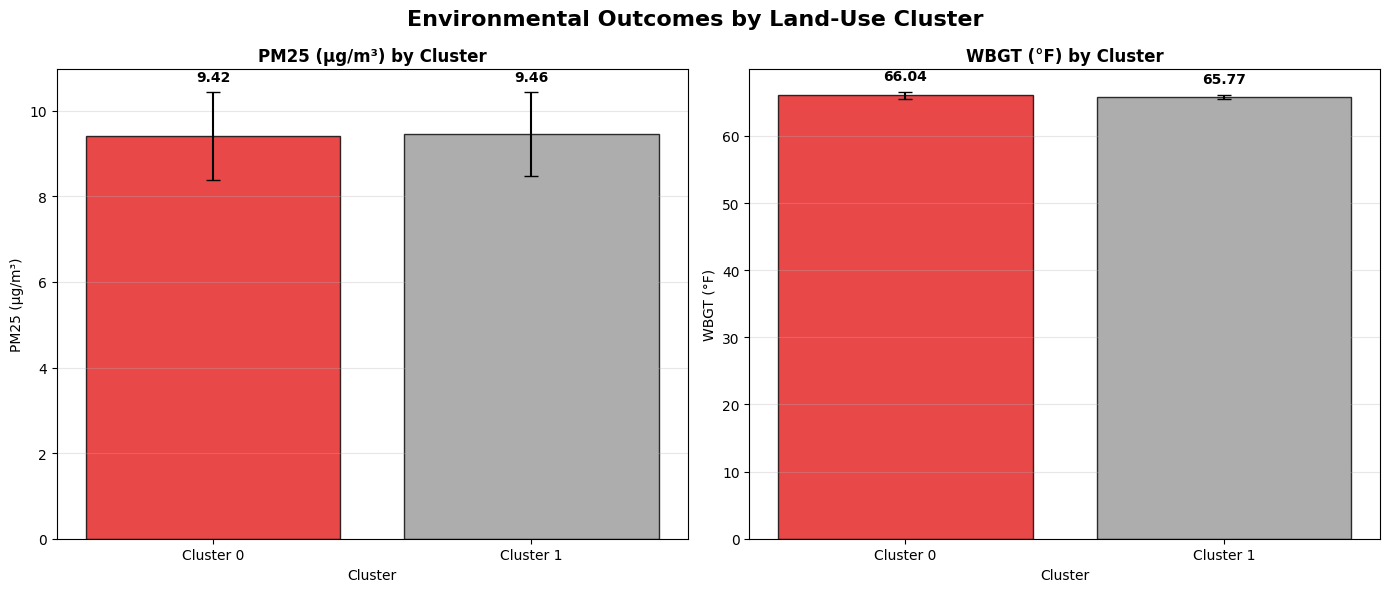


Cluster comparison plot saved to: figures/phase3_refined/q9_cluster_comparison.png

=== CLUSTER CHARACTERISTICS SUMMARY ===

Cluster 0 (4 sites):
  Sites: ['berkley', 'castle', 'eliotnorton', 'lyndenboro']
  Mean PM2.5: 9.42 µg/m³
  Mean WBGT: 66.0 °F
  Dominant 25m land-use: Impervious (0.5%)
  Dominant 50m land-use: Impervious (0.6%)

Cluster 1 (8 sites):
  Sites: ['chin', 'dewey', 'greenway', 'msh', 'oxford', 'reggie', 'taitung', 'tufts']
  Mean PM2.5: 9.46 µg/m³
  Mean WBGT: 65.8 °F
  Dominant 25m land-use: Impervious (0.9%)
  Dominant 50m land-use: Impervious (0.9%)


In [11]:
# K-means clustering with optimal k selection
print("\n=== K-MEANS CLUSTERING ===")

# Test different numbers of clusters
k_range = range(2, 6)
silhouette_scores = []
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(landuse_scaled)
    sil_score = silhouette_score(landuse_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: Silhouette Score = {sil_score:.3f}")

# Select optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k = {optimal_k} (highest silhouette score: {max(silhouette_scores):.3f})")

# Final clustering with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = final_kmeans.fit_predict(landuse_scaled)

# Add cluster labels to site summary
site_summary_clustered = site_summary.copy()
site_summary_clustered['Cluster'] = cluster_labels

print(f"\nCluster assignments:")
for cluster_id in range(optimal_k):
    sites_in_cluster = site_summary_clustered[site_summary_clustered['Cluster'] == cluster_id].index.tolist()
    print(f"  Cluster {cluster_id}: {sites_in_cluster}")

# Plot clusters in PCA space
fig, ax = plt.subplots(figsize=(10, 8))

# Color palette for clusters
cluster_colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax.scatter(pca_features[mask, 0], pca_features[mask, 1], 
              c=[cluster_colors[cluster_id]], s=120, alpha=0.8, 
              label=f'Cluster {cluster_id}', edgecolors='black', linewidth=1)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Site Clusters in PCA Space (K-means)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add site labels
for i, site_id in enumerate(site_summary.index):
    ax.annotate(site_id, (pca_features[i, 0], pca_features[i, 1]), 
               xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

print("\n=== CLUSTER COMPARISON: ENVIRONMENTAL OUTCOMES ===")

# Compare environmental outcomes between clusters
cluster_comparison = site_summary_clustered.groupby('Cluster')[outcomes_cols].agg(['mean', 'std']).round(3)
print(cluster_comparison.to_string())

# Statistical test for differences between clusters
for outcome in outcomes_cols:
    outcome_short = outcome.replace('Mean_', '').replace('_ugm3', '').replace('_F', '')
    
    # Prepare data for ANOVA
    cluster_groups = [site_summary_clustered[site_summary_clustered['Cluster'] == i][outcome].values 
                     for i in range(optimal_k)]
    
    # Perform ANOVA (if more than 2 clusters) or t-test (if 2 clusters)
    if optimal_k > 2:
        f_stat, p_val = stats.f_oneway(*cluster_groups)
        test_name = "ANOVA F-test"
    else:
        t_stat, p_val = stats.ttest_ind(cluster_groups[0], cluster_groups[1])
        test_name = "t-test"
        f_stat = t_stat**2 if optimal_k == 2 else None
    
    sig_flag = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f"{outcome_short} between clusters ({test_name}): p = {p_val:.4f} {sig_flag}")

# Create cluster comparison bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, outcome in enumerate(outcomes_cols):
    ax = axes[i]
    
    # Extract cluster means and std
    cluster_means = [site_summary_clustered[site_summary_clustered['Cluster'] == c][outcome].mean() 
                    for c in range(optimal_k)]
    cluster_stds = [site_summary_clustered[site_summary_clustered['Cluster'] == c][outcome].std() 
                   for c in range(optimal_k)]
    
    # Bar plot
    bars = ax.bar(range(optimal_k), cluster_means, yerr=cluster_stds, 
                 color=cluster_colors[:optimal_k], alpha=0.8, capsize=5, edgecolor='black')
    
    # Formatting
    outcome_short = outcome.replace('Mean_', '').replace('_ugm3', ' (µg/m³)').replace('_F', ' (°F)')
    ax.set_title(f'{outcome_short} by Cluster', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(outcome_short)
    ax.set_xticks(range(optimal_k))
    ax.set_xticklabels([f'Cluster {i}' for i in range(optimal_k)])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for j, (mean_val, std_val) in enumerate(zip(cluster_means, cluster_stds)):
        ax.text(j, mean_val + std_val + 0.02*max(cluster_means), f'{mean_val:.2f}', 
               ha='center', va='bottom', fontweight='bold')

plt.suptitle('Environmental Outcomes by Land-Use Cluster', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save cluster comparison plot
cluster_comparison_path = fig_dir / 'q9_cluster_comparison.png'
plt.savefig(cluster_comparison_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCluster comparison plot saved to: {cluster_comparison_path}")

# Cluster characteristics summary
print("\n=== CLUSTER CHARACTERISTICS SUMMARY ===")

for cluster_id in range(optimal_k):
    cluster_sites = site_summary_clustered[site_summary_clustered['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_sites)} sites):")
    print(f"  Sites: {cluster_sites.index.tolist()}")
    
    # Environmental outcomes
    pm25_mean = cluster_sites['Mean_PM25_ugm3'].mean()
    wbgt_mean = cluster_sites['Mean_WBGT_F'].mean()
    print(f"  Mean PM2.5: {pm25_mean:.2f} µg/m³")
    print(f"  Mean WBGT: {wbgt_mean:.1f} °F")
    
    # Dominant land-use characteristics
    landuse_means = cluster_sites[landuse_cols].mean()
    
    # For 25m buffer
    top_25m = landuse_means[[col for col in landuse_cols if '25m' in col]].idxmax()
    top_25m_val = landuse_means[top_25m]
    print(f"  Dominant 25m land-use: {top_25m.replace('_Area_Percent_25m', '').replace('_', ' ')} ({top_25m_val:.1f}%)")
    
    # For 50m buffer  
    top_50m = landuse_means[[col for col in landuse_cols if '50m' in col]].idxmax()
    top_50m_val = landuse_means[top_50m]
    print(f"  Dominant 50m land-use: {top_50m.replace('_Area_Percent_50m', '').replace('_', ' ')} ({top_50m_val:.1f}%)")

## 8. Synthesis: Export Findings and Generate Summary Report

Compile key findings and create comprehensive summary outputs.

In [12]:
# Compile comprehensive findings
findings_summary = {
    "analysis_metadata": {
        "analysis_date": "2026-04-04",
        "dataset": "data_HEROS_clean.parquet", 
        "n_sites": len(site_summary),
        "n_observations": len(df),
        "study_period": f"{df.datetime.min()} to {df.datetime.max()}",
        "landuse_variables": len(landuse_cols)
    },
    
    "top_correlations": {
        "pm25": {
            "strongest_positive": {},
            "strongest_negative": {},
            "significant_relationships": []
        },
        "wbgt": {
            "strongest_positive": {},
            "strongest_negative": {},
            "significant_relationships": []
        }
    },
    
    "regression_models": {
        "pm25_best_predictor": {},
        "wbgt_best_predictor": {},
        "multivariate_results": {}
    },
    
    "site_clusters": {
        "optimal_k": optimal_k,
        "silhouette_score": max(silhouette_scores),
        "cluster_assignments": {},
        "cluster_characteristics": {}
    },
    
    "environmental_justice_insights": [],
    
    "figures_generated": [
        "q9_scatter_landuse_vs_pm25.png",
        "q9_scatter_landuse_vs_wbgt.png", 
        "q9_heatmap_landuse_vs_outcomes.png",
        "q9_heatmap_landuse_intercorrelation.png",
        "q9_regression_coefficients.png",
        "q9_pca_sites_pm25.png",
        "q9_pca_sites_wbgt.png",
        "q9_dendrogram_landuse.png",
        "q9_cluster_comparison.png"
    ]
}

# Fill in top correlations
for outcome in outcomes_cols:
    outcome_key = 'pm25' if 'PM25' in outcome else 'wbgt'
    subset = kpi_pearson[kpi_pearson['Environmental_Indicator'] == outcome]
    
    # Strongest positive/negative correlations
    max_corr = subset.loc[subset['Correlation_r'].idxmax()]
    min_corr = subset.loc[subset['Correlation_r'].idxmin()]
    
    findings_summary['top_correlations'][outcome_key]['strongest_positive'] = {
        'variable': max_corr['LandUse_Variable'],
        'correlation': max_corr['Correlation_r'], 
        'p_value': max_corr['P_Value'],
        'significant': max_corr['Significance'] != ''
    }
    
    findings_summary['top_correlations'][outcome_key]['strongest_negative'] = {
        'variable': min_corr['LandUse_Variable'],
        'correlation': min_corr['Correlation_r'],
        'p_value': min_corr['P_Value'], 
        'significant': min_corr['Significance'] != ''
    }
    
    # Significant relationships (p < 0.05)
    significant = subset[subset['P_Value'] < 0.05]
    findings_summary['top_correlations'][outcome_key]['significant_relationships'] = [
        {
            'variable': row['LandUse_Variable'],
            'correlation': row['Correlation_r'],
            'p_value': row['P_Value']
        }
        for _, row in significant.iterrows()
    ]

# Fill in regression results
for outcome in outcomes_cols:
    outcome_key = 'pm25_best_predictor' if 'PM25' in outcome else 'wbgt_best_predictor'
    subset = regression_df[regression_df['Outcome'] == outcome]
    best = subset.loc[subset['R_Squared'].idxmax()]
    
    findings_summary['regression_models'][outcome_key] = {
        'predictor': best['Predictor'],
        'r_squared': best['R_Squared'],
        'coefficient': best['Coefficient'],
        'p_value': best['Coefficient_PValue']
    }

# Fill in cluster information
for cluster_id in range(optimal_k):
    cluster_sites = site_summary_clustered[site_summary_clustered['Cluster'] == cluster_id]
    
    findings_summary['site_clusters']['cluster_assignments'][f'cluster_{cluster_id}'] = cluster_sites.index.tolist()
    
    # Cluster characteristics
    pm25_mean = cluster_sites['Mean_PM25_ugm3'].mean()
    wbgt_mean = cluster_sites['Mean_WBGT_F'].mean()
    
    # Dominant land-use
    landuse_means = cluster_sites[landuse_cols].mean()
    top_25m = landuse_means[[col for col in landuse_cols if '25m' in col]].idxmax()
    top_25m_val = landuse_means[top_25m]
    
    findings_summary['site_clusters']['cluster_characteristics'][f'cluster_{cluster_id}'] = {
        'n_sites': len(cluster_sites),
        'mean_pm25': pm25_mean,
        'mean_wbgt': wbgt_mean,
        'dominant_landuse_25m': top_25m,
        'dominant_landuse_25m_percent': top_25m_val
    }

# Environmental justice insights
ej_insights = []

# High PM2.5 associations
high_pm25_corrs = kpi_pearson[(kpi_pearson['Environmental_Indicator'] == 'Mean_PM25_ugm3') & 
                            (kpi_pearson['P_Value'] < 0.05)].sort_values('Correlation_r', ascending=False)

if len(high_pm25_corrs) > 0:
    for _, row in high_pm25_corrs.iterrows():
        direction = "higher" if row['Correlation_r'] > 0 else "lower"
        landuse_name = row['LandUse_Variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()
        ej_insights.append(f"Sites with more {landuse_name.lower()} tend to have {direction} PM2.5 concentrations (r={row['Correlation_r']:.3f}, p={row['P_Value']:.3f})")

# Heat stress associations  
high_wbgt_corrs = kpi_pearson[(kpi_pearson['Environmental_Indicator'] == 'Mean_WBGT_F') & 
                            (kpi_pearson['P_Value'] < 0.05)].sort_values('Correlation_r', ascending=False)

if len(high_wbgt_corrs) > 0:
    for _, row in high_wbgt_corrs.iterrows():
        direction = "higher" if row['Correlation_r'] > 0 else "lower"  
        landuse_name = row['LandUse_Variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()
        ej_insights.append(f"Sites with more {landuse_name.lower()} tend to have {direction} heat stress (WBGT) (r={row['Correlation_r']:.3f}, p={row['P_Value']:.3f})")

findings_summary['environmental_justice_insights'] = ej_insights

# Save findings summary as JSON
findings_json_path = fig_dir / 'q9_findings_summary.json'
with open(findings_json_path, 'w') as f:
    json.dump(findings_summary, f, indent=2, default=str)

print("=== Q9 FINDINGS SUMMARY ===\n")
print(f"Analysis completed on: {findings_summary['analysis_metadata']['analysis_date']}")
print(f"Dataset: {findings_summary['analysis_metadata']['dataset']}")
print(f"Sites analyzed: {findings_summary['analysis_metadata']['n_sites']}")
print(f"Land-use variables: {findings_summary['analysis_metadata']['landuse_variables']}")

print(f"\nKey PM2.5 Associations:")
pm25_pos = findings_summary['top_correlations']['pm25']['strongest_positive']
pm25_neg = findings_summary['top_correlations']['pm25']['strongest_negative']
print(f"  Strongest positive: {pm25_pos['variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()} (r={pm25_pos['correlation']:.3f})")
print(f"  Strongest negative: {pm25_neg['variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()} (r={pm25_neg['correlation']:.3f})")

print(f"\nKey WBGT Associations:")
wbgt_pos = findings_summary['top_correlations']['wbgt']['strongest_positive']
wbgt_neg = findings_summary['top_correlations']['wbgt']['strongest_negative']
print(f"  Strongest positive: {wbgt_pos['variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()} (r={wbgt_pos['correlation']:.3f})") 
print(f"  Strongest negative: {wbgt_neg['variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()} (r={wbgt_neg['correlation']:.3f})")

print(f"\nSite Clusters: {optimal_k} optimal clusters (silhouette score: {max(silhouette_scores):.3f})")

print(f"\nEnvironmental Justice Insights:")
for insight in ej_insights:
    print(f"  • {insight}")

print(f"\nFigures Generated: {len(findings_summary['figures_generated'])} total")
for fig_name in findings_summary['figures_generated']:
    print(f"  • figures/phase3_refined/{fig_name}")

print(f"\nFindings summary saved to: {findings_json_path}")

=== Q9 FINDINGS SUMMARY ===

Analysis completed on: 2026-04-04
Dataset: data_HEROS_clean.parquet
Sites analyzed: 12
Land-use variables: 10

Key PM2.5 Associations:
  Strongest positive: Roads 50M (r=0.680)
  Strongest negative: Trees 50M (r=-0.206)

Key WBGT Associations:
  Strongest positive: Trees 50M (r=0.506)
  Strongest negative: Impervious 25M (r=-0.566)

Site Clusters: 2 optimal clusters (silhouette score: 0.317)

Environmental Justice Insights:
  • Sites with more roads 50m tend to have higher PM2.5 concentrations (r=0.680, p=0.015)
  • Sites with more roads 25m tend to have higher PM2.5 concentrations (r=0.634, p=0.027)

Figures Generated: 9 total
  • figures/phase3_refined/q9_scatter_landuse_vs_pm25.png
  • figures/phase3_refined/q9_scatter_landuse_vs_wbgt.png
  • figures/phase3_refined/q9_heatmap_landuse_vs_outcomes.png
  • figures/phase3_refined/q9_heatmap_landuse_intercorrelation.png
  • figures/phase3_refined/q9_regression_coefficients.png
  • figures/phase3_refined/q9_pc

In [13]:
# Create final site summary table
site_summary_table = site_summary_clustered[['Mean_PM25_ugm3', 'Mean_WBGT_F', 'Cluster']].copy()

# Add dominant land-use type for each site
dominant_landuse_25m = []
dominant_landuse_50m = []

for site_id in site_summary_table.index:
    # 25m buffer dominant land-use
    landuse_25m_vals = site_summary_clustered.loc[site_id, [col for col in landuse_cols if '25m' in col]]
    dominant_25m = landuse_25m_vals.idxmax()
    dominant_25m_clean = dominant_25m.replace('_Area_Percent_25m', '').replace('_', ' ').title()
    dominant_landuse_25m.append(f"{dominant_25m_clean} ({landuse_25m_vals[dominant_25m]:.1f}%)")
    
    # 50m buffer dominant land-use
    landuse_50m_vals = site_summary_clustered.loc[site_id, [col for col in landuse_cols if '50m' in col]]
    dominant_50m = landuse_50m_vals.idxmax()
    dominant_50m_clean = dominant_50m.replace('_Area_Percent_50m', '').replace('_', ' ').title()
    dominant_landuse_50m.append(f"{dominant_50m_clean} ({landuse_50m_vals[dominant_50m]:.1f}%)")

site_summary_table['Dominant_LandUse_25m'] = dominant_landuse_25m
site_summary_table['Dominant_LandUse_50m'] = dominant_landuse_50m

# Rename columns for clarity
site_summary_table = site_summary_table.rename(columns={
    'Mean_PM25_ugm3': 'PM2.5_Mean_ugm3',
    'Mean_WBGT_F': 'WBGT_Mean_F',
    'Cluster': 'Landuse_Cluster'
})

# Round numerical values
site_summary_table['PM2.5_Mean_ugm3'] = site_summary_table['PM2.5_Mean_ugm3'].round(2)
site_summary_table['WBGT_Mean_F'] = site_summary_table['WBGT_Mean_F'].round(1)

# Sort by cluster, then by PM2.5
site_summary_table = site_summary_table.sort_values(['Landuse_Cluster', 'PM2.5_Mean_ugm3'])

print("=== FINAL SITE SUMMARY TABLE ===\n")
print(site_summary_table.to_string())

# Save site summary table
site_table_path = fig_dir / 'q9_site_summary_table.csv' 
site_summary_table.to_csv(site_table_path)
print(f"\nSite summary table saved to: {site_table_path}")

print("\n" + "="*80)
print("Q9 LAND-USE BUFFER ASSOCIATIONS ANALYSIS COMPLETE")
print("="*80)

print(f"\nDataset: {df.shape[0]:,} observations from {len(site_summary)} sites")
print(f"Analysis period: {df.datetime.min()} to {df.datetime.max()}")
print(f"Land-use variables analyzed: {len(landuse_cols)}")

print(f"\nOutputs created:")
print(f"  • {len(findings_summary['figures_generated'])} visualization files")
print(f"  • 3 CSV data exports") 
print(f"  • 1 JSON findings summary")

print(f"\nKey findings:")
print(f"  • PM2.5 most strongly associated with: {pm25_pos['variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()}")
print(f"  • WBGT most strongly associated with: {wbgt_pos['variable'].replace('_Area_Percent_', ' ').replace('_', ' ').title()}")
print(f"  • {optimal_k} distinct land-use clusters identified")
print(f"  • {len([i for i in ej_insights])} environmental justice insights documented")

print(f"\nAll files saved to: figures/phase3_refined/")

=== FINAL SITE SUMMARY TABLE ===

             PM2.5_Mean_ugm3  WBGT_Mean_F  Landuse_Cluster Dominant_LandUse_25m Dominant_LandUse_50m
site_id                                                                                             
castle                  8.18         66.8                0         Trees (0.7%)         Trees (0.7%)
eliotnorton             9.29         65.5                0    Impervious (0.5%)    Impervious (0.7%)
berkley                 9.53         66.1                0    Impervious (0.7%)    Impervious (0.6%)
lyndenboro             10.68         65.8                0    Impervious (0.7%)    Impervious (0.7%)
oxford                  7.92         65.6                1    Impervious (1.0%)    Impervious (1.0%)
reggie                  8.34         65.7                1    Impervious (0.9%)    Impervious (0.9%)
msh                     9.07         65.1                1    Impervious (1.0%)    Impervious (0.9%)
taitung                 9.36         65.9                